# 🚀 GoViralIQ
## Notebook 5: NLP Pipeline
**Project:** Predicting Instagram Engagement & Auditing Algorithmic Fairness Across Creator Niches  
**Author:** Chastity Lewis  
**Course:** CISC 540 — Computational Data Analysis | Mercy University | Spring 2026  

---

### 📌 Notebook Goals
In this notebook we will:
1. Tokenize and clean hashtag text using NLTK
2. Remove stopwords and apply stemming
3. Perform sentiment analysis using NLTK VADER
4. Apply TF-IDF vectorization
5. Analyze sentiment patterns across viral vs non-viral posts
6. Identify top keywords that drive engagement
7. Save NLP features for the fairness audit

---

## Step 1: Install & Import Libraries

In [1]:
# Install NLTK
!pip install nltk --quiet

import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import re

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PURPLE       = '#6B21A8'
LIGHT_PURPLE = '#D8B4FE'
MID_PURPLE   = '#9333EA'
COLORS       = [PURPLE, LIGHT_PURPLE, MID_PURPLE, '#A855F7', '#7C3AED']

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 2: Load the Clean Dataset

In [2]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'✅ Loaded: {filename}')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Saving goviraliq_instagram_raw.csv to goviraliq_instagram_raw.csv
✅ Loaded: goviraliq_instagram_raw.csv
📊 Shape: 1,212 rows × 12 columns


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level,engagement_rate,viral
0,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium,7.4192,0
1,Post_6,Instagram,#Challenge,Shorts,Australia,1323566,136282,86979,47129,Low,20.4289,0
2,Post_11,Instagram,#Comedy,Live Stream,Germany,4070332,379894,46012,25242,High,11.0838,0
3,Post_27,Instagram,#Gaming,Video,India,4369260,212278,21264,18172,Low,5.7610,0
4,Post_29,Instagram,#Gaming,Live Stream,Canada,1653907,91836,77370,2823,Low,10.4014,0


## Step 3: Text Cleaning & Tokenization

In [12]:
import nltk
nltk.download('punkt_tab', quiet=True)

# Initialize tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    """Clean and normalize hashtag text"""
    if pd.isna(text):
        return ''
    # Remove # symbol and convert to lowercase
    text = str(text).replace('#', ' ').lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

def tokenize_and_stem(text):
    """Tokenize, remove stopwords, and apply stemming"""
    if not text:
        return []
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

# Apply cleaning
df['hashtag_clean'] = df['Hashtag'].apply(clean_text)
df['hashtag_tokens'] = df['hashtag_clean'].apply(tokenize_and_stem)
df['hashtag_token_count'] = df['hashtag_tokens'].apply(len)

print('✅ Text cleaning complete!')
print(f'\nSample cleaned hashtags:')
for i in range(5):
    print(f'  Original: {df["Hashtag"].iloc[i]}')
    print(f'  Cleaned:  {df["hashtag_clean"].iloc[i]}')
    print(f'  Tokens:   {df["hashtag_tokens"].iloc[i]}')
    print()

✅ Text cleaning complete!

Sample cleaned hashtags:
  Original: #Education
  Cleaned:  education
  Tokens:   ['educ']

  Original: #Challenge
  Cleaned:  challenge
  Tokens:   ['challeng']

  Original: #Comedy
  Cleaned:  comedy
  Tokens:   ['comedi']

  Original: #Gaming
  Cleaned:  gaming
  Tokens:   ['game']

  Original: #Gaming
  Cleaned:  gaming
  Tokens:   ['game']



## Step 4: Sentiment Analysis with NLTK VADER
> **VADER** (Valence Aware Dictionary and sEntiment Reasoner) is specifically designed for social media text.  
> It returns scores for: positive, negative, neutral, and compound (overall sentiment -1 to +1)

In [10]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Return VADER sentiment scores"""
    if not text:
        return {'neg': 0, 'neu': 1, 'pos': 0, 'compound': 0}
    return sia.polarity_scores(text)

# Apply VADER to cleaned hashtags
sentiment_scores = df['hashtag_clean'].apply(get_sentiment)
df['sentiment_neg']      = sentiment_scores.apply(lambda x: x['neg'])
df['sentiment_neu']      = sentiment_scores.apply(lambda x: x['neu'])
df['sentiment_pos']      = sentiment_scores.apply(lambda x: x['pos'])
df['sentiment_compound'] = sentiment_scores.apply(lambda x: x['compound'])

# Classify sentiment
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_compound'].apply(classify_sentiment)

print('✅ Sentiment analysis complete!')
print(f'\nSentiment distribution:')
print(df['sentiment_label'].value_counts())
print(f'\nAverage compound sentiment: {df["sentiment_compound"].mean():.4f}')

✅ Sentiment analysis complete!

Sentiment distribution:
sentiment_label
Neutral     829
Positive    383
Name: count, dtype: int64

Average compound sentiment: 0.0756


## Step 5: Visualize Sentiment Patterns

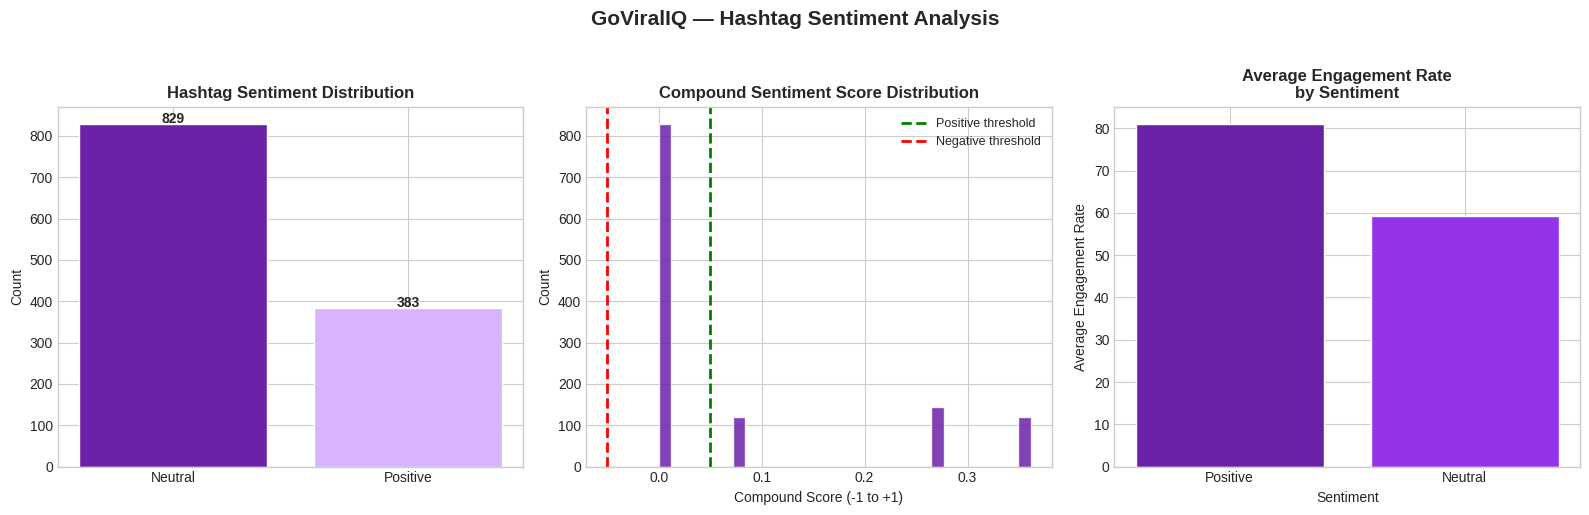

✅ Saved nlp_01_sentiment_overview.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sentiment distribution
sent_counts = df['sentiment_label'].value_counts()
axes[0].bar(sent_counts.index, sent_counts.values,
            color=[PURPLE, LIGHT_PURPLE, MID_PURPLE], edgecolor='white')
for i, (label, count) in enumerate(sent_counts.items()):
    axes[0].text(i, count + 2, f'{count:,}', ha='center', fontweight='bold')
axes[0].set_title('Hashtag Sentiment Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Sentiment compound score distribution
axes[1].hist(df['sentiment_compound'], bins=30, color=PURPLE, edgecolor='white', alpha=0.85)
axes[1].axvline(0.05, color='green', linestyle='--', linewidth=2, label='Positive threshold')
axes[1].axvline(-0.05, color='red', linestyle='--', linewidth=2, label='Negative threshold')
axes[1].set_title('Compound Sentiment Score Distribution', fontweight='bold')
axes[1].set_xlabel('Compound Score (-1 to +1)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# Sentiment vs Engagement Rate
sentiment_eng = df.groupby('sentiment_label')['engagement_rate'].mean().sort_values(ascending=False)
axes[2].bar(sentiment_eng.index, sentiment_eng.values,
            color=[PURPLE, MID_PURPLE, LIGHT_PURPLE], edgecolor='white')
axes[2].set_title('Average Engagement Rate\nby Sentiment', fontweight='bold')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Average Engagement Rate')

plt.suptitle('GoViralIQ — Hashtag Sentiment Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nlp_01_sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved nlp_01_sentiment_overview.png')

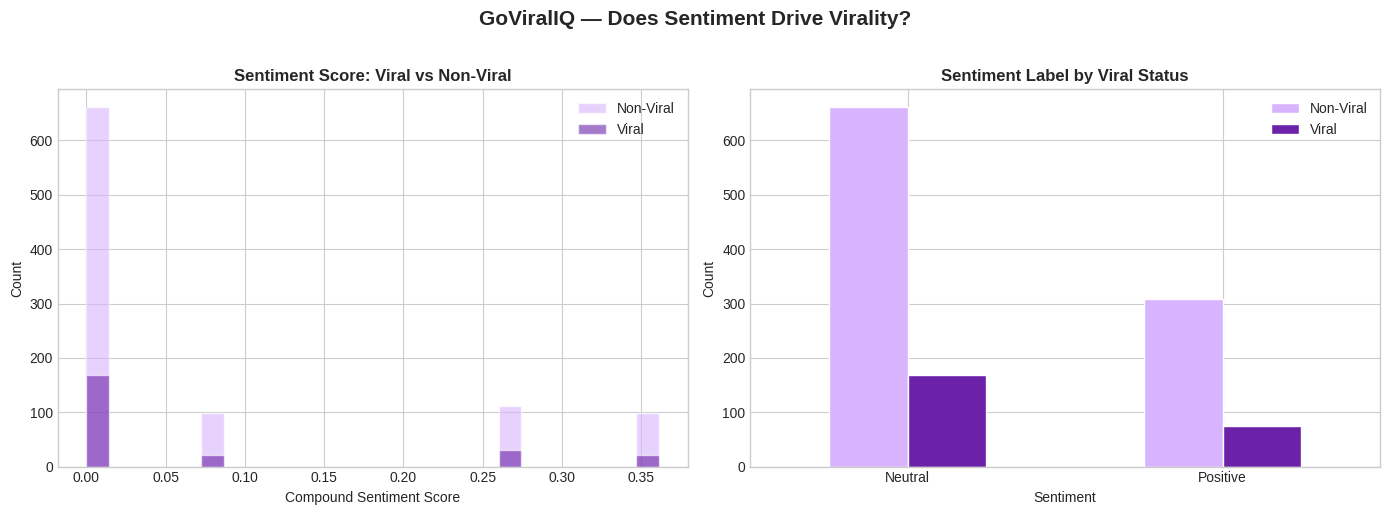

✅ Saved nlp_02_sentiment_viral.png


In [13]:
# Sentiment by viral vs non-viral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compound score: viral vs non-viral
viral_sent    = df[df['viral'] == 1]['sentiment_compound']
nonviral_sent = df[df['viral'] == 0]['sentiment_compound']

axes[0].hist(nonviral_sent, bins=25, alpha=0.6, color=LIGHT_PURPLE, edgecolor='white', label='Non-Viral')
axes[0].hist(viral_sent, bins=25, alpha=0.6, color=PURPLE, edgecolor='white', label='Viral')
axes[0].set_title('Sentiment Score: Viral vs Non-Viral', fontweight='bold')
axes[0].set_xlabel('Compound Sentiment Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Sentiment label breakdown by viral
sent_viral = df.groupby(['sentiment_label', 'viral']).size().unstack(fill_value=0)
sent_viral.plot(kind='bar', ax=axes[1], color=[LIGHT_PURPLE, PURPLE], edgecolor='white')
axes[1].set_title('Sentiment Label by Viral Status', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].legend(['Non-Viral', 'Viral'])
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('GoViralIQ — Does Sentiment Drive Virality?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nlp_02_sentiment_viral.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved nlp_02_sentiment_viral.png')

## Step 6: TF-IDF Vectorization
> **TF-IDF** (Term Frequency-Inverse Document Frequency) finds the most important words in each post relative to the whole dataset.

In [14]:
# Apply TF-IDF
tfidf = TfidfVectorizer(max_features=50, stop_words='english', min_df=2)
tfidf_matrix = tfidf.fit_transform(df['hashtag_clean'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print(f'✅ TF-IDF complete!')
print(f'   Vocabulary size: {len(tfidf.vocabulary_)} terms')
print(f'   Matrix shape: {tfidf_matrix.shape}')
print(f'\nTop 20 most important terms:')
term_scores = tfidf_df.mean().sort_values(ascending=False).head(20)
print(term_scores)

✅ TF-IDF complete!
   Vocabulary size: 10 terms
   Matrix shape: (1212, 10)

Top 20 most important terms:
fitness      0.117987
education    0.108086
music        0.104785
dance        0.099835
comedy       0.099010
challenge    0.099010
fashion      0.095710
gaming       0.094059
tech         0.090759
viral        0.090759
dtype: float64


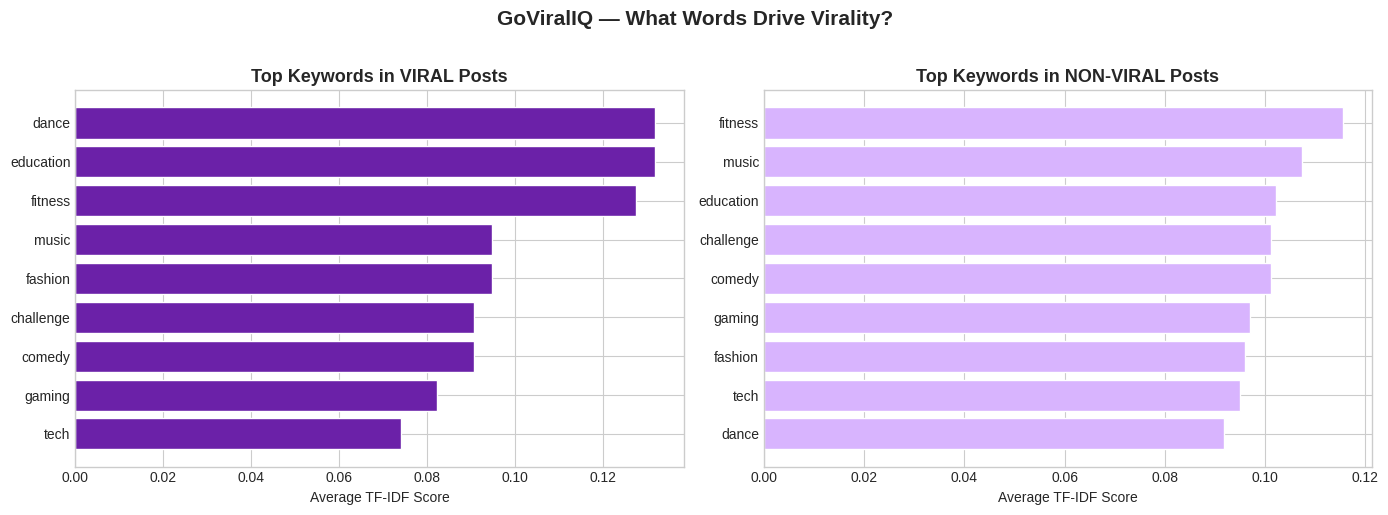

✅ Saved nlp_03_tfidf_keywords.png


In [15]:
# Top keywords for viral vs non-viral posts
tfidf_df['viral'] = df['viral'].values

viral_terms    = tfidf_df[tfidf_df['viral'] == 1].drop('viral', axis=1).mean().sort_values(ascending=False).head(10)
nonviral_terms = tfidf_df[tfidf_df['viral'] == 0].drop('viral', axis=1).mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Viral keywords
axes[0].barh(viral_terms.index[::-1], viral_terms.values[::-1], color=PURPLE, edgecolor='white')
axes[0].set_title('Top Keywords in VIRAL Posts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average TF-IDF Score')

# Non-viral keywords
axes[1].barh(nonviral_terms.index[::-1], nonviral_terms.values[::-1], color=LIGHT_PURPLE, edgecolor='white')
axes[1].set_title('Top Keywords in NON-VIRAL Posts', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average TF-IDF Score')

plt.suptitle('GoViralIQ — What Words Drive Virality?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nlp_03_tfidf_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved nlp_03_tfidf_keywords.png')

## Step 7: Sentiment by Content Type

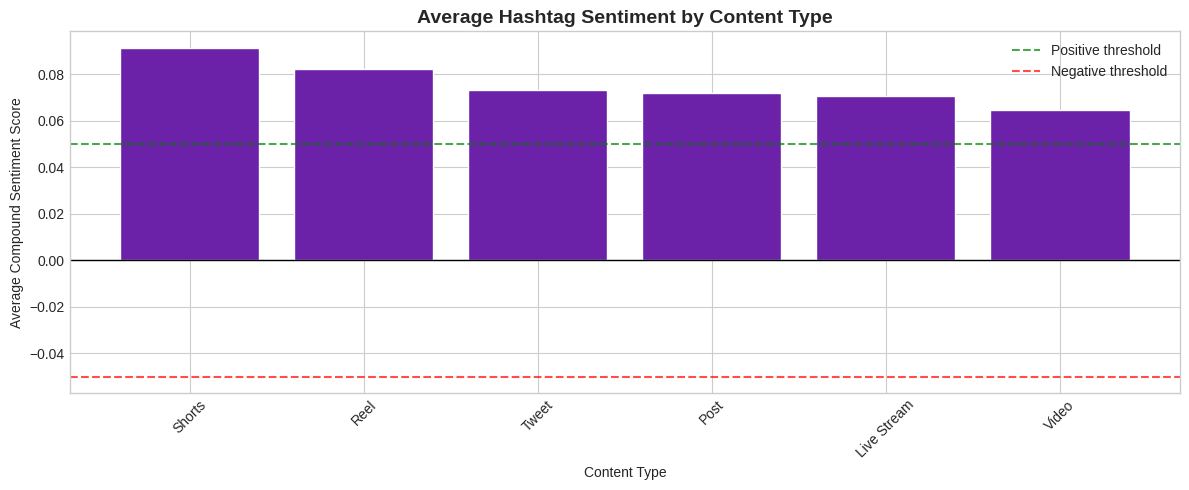

✅ Saved nlp_04_sentiment_by_content.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

content_sentiment = df.groupby('Content_Type')['sentiment_compound'].mean().sort_values(ascending=False)
colors_bar = [PURPLE if v > 0 else LIGHT_PURPLE for v in content_sentiment.values]
bars = ax.bar(content_sentiment.index, content_sentiment.values, color=colors_bar, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(0.05, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Positive threshold')
ax.axhline(-0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Negative threshold')
ax.set_title('Average Hashtag Sentiment by Content Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Type')
ax.set_ylabel('Average Compound Sentiment Score')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig('nlp_04_sentiment_by_content.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved nlp_04_sentiment_by_content.png')

## Step 8: Save Dataset with NLP Features

In [17]:
# Save dataset with all NLP features added
df.to_csv('goviraliq_nlp_features.csv', index=False)

print('✅ Saved goviraliq_nlp_features.csv')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nNew NLP columns added:')
nlp_cols = ['hashtag_clean', 'hashtag_tokens', 'hashtag_token_count',
            'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
            'sentiment_compound', 'sentiment_label']
for col in nlp_cols:
    print(f'  - {col}')
print(f'\n📁 Files created this notebook:')
print('   - goviraliq_nlp_features.csv')
print('   - nlp_01_sentiment_overview.png')
print('   - nlp_02_sentiment_viral.png')
print('   - nlp_03_tfidf_keywords.png')
print('   - nlp_04_sentiment_by_content.png')

✅ Saved goviraliq_nlp_features.csv
   Shape: 1,212 rows × 20 columns

New NLP columns added:
  - hashtag_clean
  - hashtag_tokens
  - hashtag_token_count
  - sentiment_neg
  - sentiment_neu
  - sentiment_pos
  - sentiment_compound
  - sentiment_label

📁 Files created this notebook:
   - goviraliq_nlp_features.csv
   - nlp_01_sentiment_overview.png
   - nlp_02_sentiment_viral.png
   - nlp_03_tfidf_keywords.png
   - nlp_04_sentiment_by_content.png


## Step 9: NLP Summary

In [18]:
print('=' * 55)
print('       GoViralIQ — Notebook 5 Summary')
print('=' * 55)
print(f'\n📝 Text Processing:')
print(f'   Total posts analyzed:     {len(df):,}')
print(f'   Avg tokens per hashtag:   {df["hashtag_token_count"].mean():.1f}')
print(f'   TF-IDF vocabulary size:   {len(tfidf.vocabulary_)} terms')
print(f'\n💬 Sentiment Distribution:')
for label, count in df['sentiment_label'].value_counts().items():
    print(f'   {label}: {count:,} ({count/len(df)*100:.1f}%)')
print(f'\n📊 Sentiment vs Engagement:')
for label, eng in df.groupby('sentiment_label')['engagement_rate'].mean().items():
    print(f'   {label} sentiment avg engagement: {eng:.4f}')
print(f'\n🔑 Top viral keyword: {viral_terms.index[0]}')
print(f'🔑 Top non-viral keyword: {nonviral_terms.index[0]}')
print('\n' + '=' * 55)
print('\n✅ Next: Notebook 06 — Fairness Audit')

       GoViralIQ — Notebook 5 Summary

📝 Text Processing:
   Total posts analyzed:     1,212
   Avg tokens per hashtag:   1.0
   TF-IDF vocabulary size:   10 terms

💬 Sentiment Distribution:
   Neutral: 829 (68.4%)
   Positive: 383 (31.6%)

📊 Sentiment vs Engagement:
   Neutral sentiment avg engagement: 59.3377
   Positive sentiment avg engagement: 81.0717

🔑 Top viral keyword: dance
🔑 Top non-viral keyword: fitness


✅ Next: Notebook 06 — Fairness Audit
